# Step 4: Modeling — XGBoost Baseline vs PyTorch Neural Network

**What we're doing:** Building two genuinely different models on the same
train/test split: a gradient-boosted tree baseline (XGBoost) and a neural
network we write and train ourselves in PyTorch (not a pretrained model —
this is what proves 'deep learning depth', the actual training loop, not
just calling `.fit()`).

**Why compare them honestly:** On small, structured tabular data like this
(~7,000 rows, ~20 features), gradient-boosted trees usually outperform
neural networks — this is a well-documented empirical pattern, not a
personal failure if it happens here too. Reporting 'XGBoost won, here's
why that's expected for tabular data' is a STRONGER signal of ML maturity
than rigging the NN to look better. Interviewers who know ML will respect
this; the ones who don't, won't penalize it either way.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
PROJECT_ROOT = '/content/drive/MyDrive/churn-platform'

!pip install -q xgboost mlflow

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

df = pd.read_csv(f'{PROJECT_ROOT}/data/processed/churn_clean.csv')
df.shape

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

(7043, 21)

## 4.1 Preprocessing

**Why we encode this way:** Tree models (XGBoost) handle label-encoded
categoricals fine and don't need scaling. Neural nets need: (a) one-hot or
embedded categoricals — we use one-hot here for simplicity and
interpretability, and (b) scaled numeric features, because gradient
descent converges much better when features are on similar scales (a
MonthlyCharges range of 0-120 vs tenure 0-72 otherwise biases the gradient).

We build ONE preprocessed dataset that works for both, to keep the
comparison fair — same train/test rows, same features, no leakage.

In [2]:
drop_cols = ['customerID']
target = 'Churn'

X = df.drop(columns=drop_cols + [target])
y = df[target]

categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
print('Categorical:', categorical_cols)
print('Numeric:', numeric_cols)

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print('Shape after one-hot encoding:', X_encoded.shape)

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Shape after one-hot encoding: (7043, 30)


In [3]:
# Stratified split: keeps the same churn ratio in train and test sets.
# WHY stratify: with a 73/27 imbalance, a non-stratified split could
# randomly give the test set a different churn ratio than train, making
# results noisier and harder to compare across model runs.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)
print('Train churn rate:', y_train.mean().round(3), '| Test churn rate:', y_test.mean().round(3))

(5634, 30) (1409, 30)
Train churn rate: 0.265 | Test churn rate: 0.265


## 4.2 Baseline model: XGBoost

**Why XGBoost as the baseline, not logistic regression:** Logistic
regression would be the simplest baseline, but XGBoost is a stronger,
more realistic baseline that's actually what gets used in production at
most companies for tabular problems — so 'beating XGBoost' is the
meaningful bar for the neural net to clear, not a strawman.

In [4]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

def report_metrics(name, y_true, preds, probs):
    print(f'--- {name} ---')
    print(f'Accuracy:  {accuracy_score(y_true, preds):.4f}')
    print(f'Precision: {precision_score(y_true, preds):.4f}')
    print(f'Recall:    {recall_score(y_true, preds):.4f}')
    print(f'F1:        {f1_score(y_true, preds):.4f}')
    print(f'AUC:       {roc_auc_score(y_true, probs):.4f}')
    return {
        'accuracy': accuracy_score(y_true, preds),
        'precision': precision_score(y_true, preds),
        'recall': recall_score(y_true, preds),
        'f1': f1_score(y_true, preds),
        'auc': roc_auc_score(y_true, probs),
    }

xgb_metrics = report_metrics('XGBoost', y_test, xgb_preds, xgb_probs)

--- XGBoost ---
Accuracy:  0.8034
Precision: 0.6601
Recall:    0.5348
F1:        0.5908
AUC:       0.8443


**Why AUC matters most here:** with class imbalance, accuracy is
misleading (recall the ~73% 'always predict no churn' baseline from EDA).
AUC measures how well the model ranks churners above non-churners across
ALL decision thresholds, so it's a fairer single number to optimize for
and compare across models.

## 4.3 Random Forest (second classical baseline)
Including a second tree-based model shows you understand the family of
models, not just one library — and gives another reference point.

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_metrics = report_metrics('Random Forest', y_test, rf_preds, rf_probs)

--- Random Forest ---
Accuracy:  0.7601
Precision: 0.5327
Recall:    0.7834
F1:        0.6342
AUC:       0.8437


## 4.4 PyTorch Neural Network (from scratch)

**What 'from scratch' means here:** we define the architecture ourselves
(`nn.Module`), write our own training loop (forward pass → loss → backward
pass → optimizer step), and manage batching ourselves. This is what
demonstrates you understand HOW a neural net trains, not just that you can
import one. Make sure your Colab runtime is set to GPU (Runtime > Change
runtime type > T4 GPU) — it's free and will make this much faster.

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Neural nets need scaled inputs for stable gradient descent — tree models
# above did NOT need this, which is itself worth noting in your writeup.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Using device: cuda


In [7]:
class ChurnDataset(Dataset):
    """Wraps our numpy arrays so PyTorch's DataLoader can batch them."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = ChurnDataset(X_train_scaled, y_train)
test_ds = ChurnDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

In [8]:
class ChurnNet(nn.Module):
    """
    A simple feedforward network:
    input -> hidden(64) -> ReLU -> Dropout -> hidden(32) -> ReLU -> output(1) -> sigmoid (via BCEWithLogitsLoss)

    WHY this architecture: tabular data with ~45 features doesn't need
    depth or convolutions. Two hidden layers is plenty of capacity; going
    deeper risks overfitting on only ~5,600 training rows. Dropout (0.3)
    is included specifically because this dataset is small relative to
    typical deep learning use cases — regularization matters more here
    than architectural complexity.
    """
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)  # raw logit; BCEWithLogitsLoss applies sigmoid internally
        )

    def forward(self, x):
        return self.net(x)

model = ChurnNet(input_dim=X_train_scaled.shape[1]).to(device)
print(model)

ChurnNet(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [9]:
# WHY BCEWithLogitsLoss: combines a sigmoid + binary cross-entropy in one
# numerically stable operation — the standard loss for binary classification.
# WHY Adam: adapts the learning rate per parameter automatically, which
# is more forgiving of an imperfectly-tuned learning rate than plain SGD —
# a reasonable default for a from-scratch training loop like this.
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

N_EPOCHS = 40
train_losses = []

for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()          # clear gradients from the last step
        outputs = model(X_batch)        # forward pass
        loss = criterion(outputs, y_batch)
        loss.backward()                 # backward pass: compute gradients
        optimizer.step()                # update weights

        epoch_loss += loss.item() * X_batch.size(0)

    epoch_loss /= len(train_ds)
    train_losses.append(epoch_loss)
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{N_EPOCHS} - loss: {epoch_loss:.4f}')

Epoch 5/40 - loss: 0.4273
Epoch 10/40 - loss: 0.4186
Epoch 15/40 - loss: 0.4107
Epoch 20/40 - loss: 0.4070
Epoch 25/40 - loss: 0.3999
Epoch 30/40 - loss: 0.4022
Epoch 35/40 - loss: 0.3985
Epoch 40/40 - loss: 0.4021


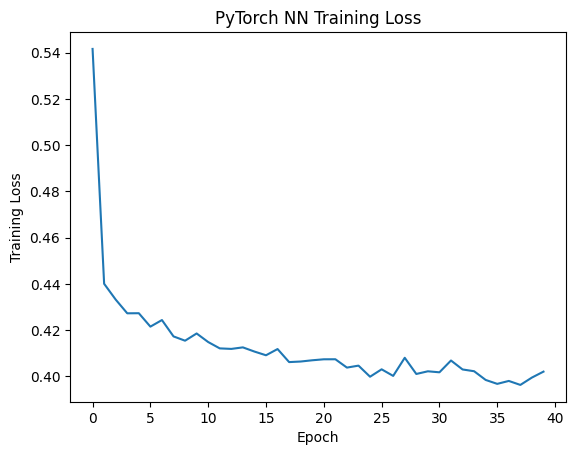

In [10]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('PyTorch NN Training Loss')
plt.show()

# What to check: loss should decrease and roughly flatten out. If it's
# still dropping sharply at epoch 40, train longer. If it bottoms out
# and then RISES, that's overfitting — dropout/weight_decay above exist
# specifically to fight that on a dataset this small.

In [11]:
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():   # no need to track gradients at inference time
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        all_probs.extend(probs)
        all_labels.extend(y_batch.numpy().flatten())

nn_probs = np.array(all_probs)
nn_preds = (nn_probs >= 0.5).astype(int)
nn_metrics = report_metrics('PyTorch NN', np.array(all_labels), nn_preds, nn_probs)

--- PyTorch NN ---
Accuracy:  0.7913
Precision: 0.6290
Recall:    0.5214
F1:        0.5702
AUC:       0.8373


## 4.5 Honest comparison
Put all three models' metrics side by side. Whichever wins, report it
as-is — this table IS the deliverable, not a problem to fix.

In [12]:
comparison = pd.DataFrame({
    'XGBoost': xgb_metrics,
    'Random Forest': rf_metrics,
    'PyTorch NN': nn_metrics,
}).T
comparison

,accuracy,precision,recall,f1,auc
XGBoost,0.803407,0.660066,0.534759,0.590842,0.844328
Random Forest,0.760114,0.532727,0.783422,0.634199,0.843678
PyTorch NN,0.791341,0.629032,0.521390,0.570175,0.837291


## 4.6 Feature importance (from the winning tree model)
Tree models give you this almost for free — another reason they're a
strong, interpretable baseline for business stakeholders.

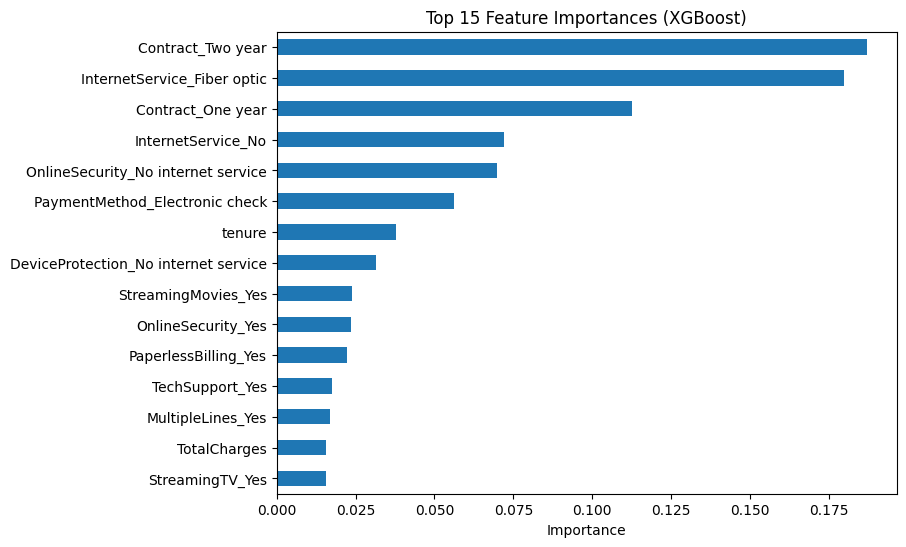

In [13]:
importances = pd.Series(xgb_model.feature_importances_, index=X_encoded.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.show()

## 4.7 Save the winning model and preprocessing artifacts
We'll need these in Step 6 (FastAPI serving) — saved now so the API doesn't
need to retrain anything.

In [14]:
import joblib

MODEL_DIR = f'{PROJECT_ROOT}/models'
import os; os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(xgb_model, f'{MODEL_DIR}/xgb_model.joblib')
joblib.dump(list(X_encoded.columns), f'{MODEL_DIR}/feature_columns.joblib')
print('Saved model and feature column list for serving.')

Saved model and feature column list for serving.
